# Bloc 01 - Plan your trip with Kayak 

## 04 - ETL

Import de librairies

In [27]:
import os

import boto3
import pandas as pd
from dotenv import load_dotenv
from IPython.display import Image, display
from sqlalchemy import Column, Float, Integer, MetaData, String, Table, create_engine

load_dotenv()

True

In [28]:
# Variables d'environnement
AWS_ACCESS_KEY_ID = os.environ["AWS_ACCESS_KEY_ID"]
AWS_SECRET_ACCESS_KEY = os.environ["AWS_SECRET_ACCESS_KEY"]

bucket_name = os.environ["BUCKET_NAME"]

s3 = boto3.client(
    "s3",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name="eu-west-3"
)

### Récupération des fichiers csv depuis S3

In [29]:
csv_cities_data = pd.read_csv(f"s3://{bucket_name}/cities.csv")
csv_hotels_data = pd.read_csv(f"s3://{bucket_name}/scrap_booking.csv")

In [30]:
print(csv_cities_data)

                            city      lat     lon  city_score  \
0                     Strasbourg  48.5846  7.7507    2.428571   
1                       Le Havre  49.4939  0.1080    1.857143   
2                          Lille  50.6366  3.0635    1.857143   
3                          Paris  48.8535  2.3484    1.857143   
4                         Amiens  49.8942  2.2957    1.714286   
5                         Colmar  48.0778  7.3580    1.714286   
6                          Rouen  49.4405  1.0940    1.714286   
7                       Besancon  47.2380  6.0244    1.571429   
8                          Dijon  47.3216  5.0415    1.571429   
9                         Annecy  45.8992  6.1289    1.428571   
10  Chateau du Haut Koenigsbourg  48.2494  7.3439    1.428571   
11                     Eguisheim  48.0448  7.3080    1.428571   
12                        Bayeux  49.2765 -0.7025    1.285714   
13              Gorges du Verdon  43.7497  6.3286    1.142857   
14                       

In [31]:
print(csv_hotels_data)

                  city        lat       lon  \
0    Mont Saint Michel  48.577087 -1.562743   
1    Mont Saint Michel  48.713811 -1.489071   
2    Mont Saint Michel  48.714573 -1.485254   
3    Mont Saint Michel  48.631960 -1.389475   
4    Mont Saint Michel  48.555020 -1.512412   
..                 ...        ...       ...   
695            St Malo  48.653695 -2.010813   
696  Mont Saint Michel  48.615381 -1.510710   
697  Mont Saint Michel  48.617587 -1.510396   
698  Mont Saint Michel  48.616263 -1.510906   
699  Mont Saint Michel  48.614247 -1.510545   

                                           name  \
0                                A place of zen   
1                                   Petit Bijou   
2                      Le Domaine de Belleville   
3                                   Rue Veillon   
4    L'Orée du Mont proche du mont saint Michel   
..                                          ...   
695            Studio Le sillon malouin vue mer   
696                        

### Insertion dans Postgresql

In [ ]:
DBHOST = os.environ["DBHOST"]
DBUSER = os.environ["DBUSER"]
DBPASS = os.environ["DBPASS"]
DBNAME = os.environ["DBNAME"]
PORT = os.environ["PORT"]

engine = create_engine(f"postgresql+psycopg2://{DBUSER}:{DBPASS}@{DBHOST}:{PORT}/{DBNAME}", echo=True)

In [35]:
meta = MetaData()

city_table = Table(
    'city', meta,
    Column("id", Integer, primary_key=True, autoincrement=True),
    Column('city', String(255)),
    Column('lat', Float),
    Column('lon', Float),
    Column('city_score', Float),
    Column('score_normalized', Float),
)

hotel_table = Table(
    'hotel', meta,
    Column("id", Integer, primary_key=True, autoincrement=True),
    Column('name', String(255)),
    Column('lat', Float),
    Column('lon', Float),
    Column('url', String(1000)),
    Column('review_score', Float),
    Column('desc', String(5000)),
    Column('city_id', Integer),
    
)

meta.create_all(engine, checkfirst=True)

2026-03-12 23:30:22,268 INFO sqlalchemy.engine.Engine select pg_catalog.version()
2026-03-12 23:30:22,269 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-03-12 23:30:22,283 INFO sqlalchemy.engine.Engine select current_schema()
2026-03-12 23:30:22,284 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-03-12 23:30:22,298 INFO sqlalchemy.engine.Engine show standard_conforming_strings
2026-03-12 23:30:22,298 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-03-12 23:30:22,312 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-03-12 23:30:22,317 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname

In [36]:
csv_cities_data.to_sql(
    "city",
    engine,
    if_exists="append",
    index=False
)

2026-03-12 23:30:30,377 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-03-12 23:30:30,382 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-03-12 23:30:30,385 INFO sqlalchemy.engine.Engine [cached since 8.068s ago] {'table_name': 'city', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-03-12 23:30:30,405 INFO sqlalchemy.engine.Engine INSERT INTO city (city, lat, lon, city_score, score_normalized) VALUES (%(city__0)s, %(lat__0)s, %(lon__0)s, %(city_score__0)s, %(score_normalized__0)s), (%(city__1)s, %(lat__1)s,

35

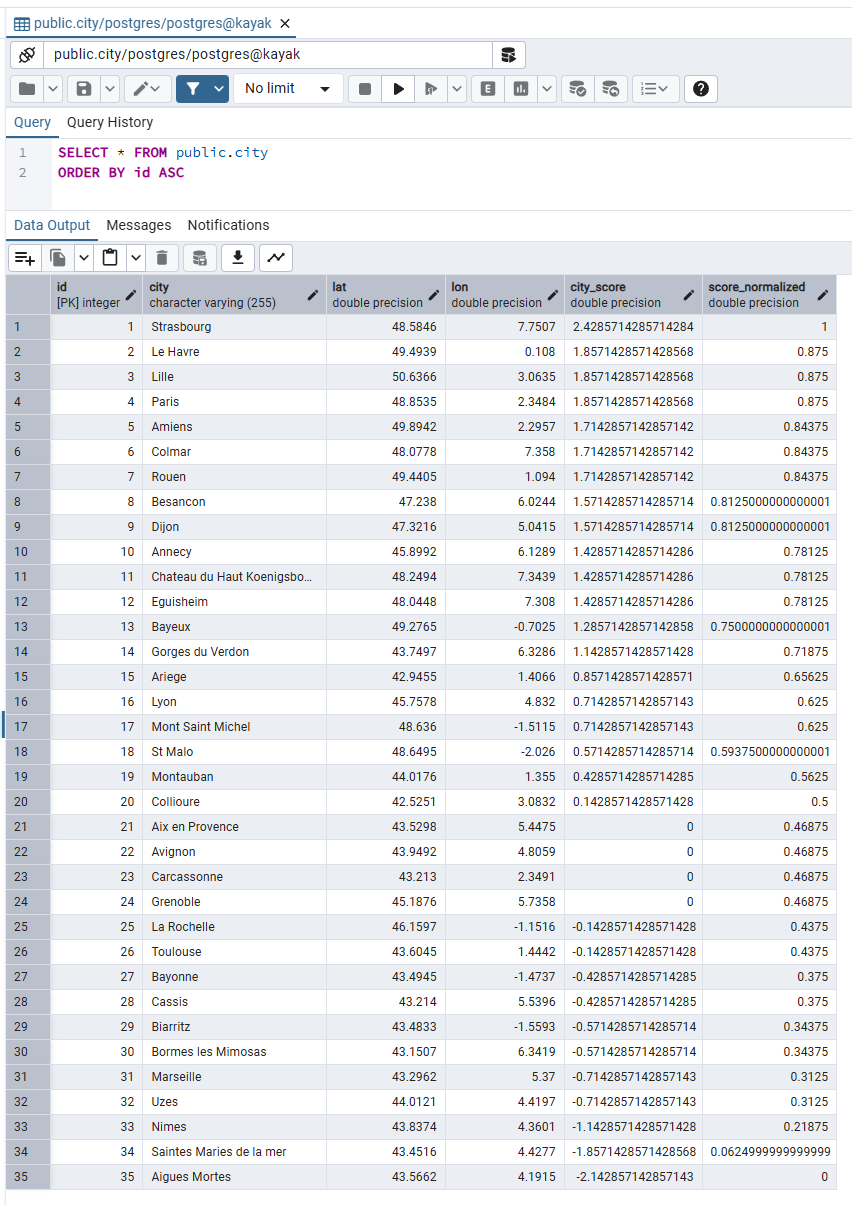

In [40]:
display(Image(filename="../images/city_table.png"))

In [37]:
# récuperation de city_id
cities_query = pd.read_sql("SELECT id, city FROM city", engine)
city_map = dict(zip(cities_query["city"], cities_query["id"]))

csv_hotels_data["city_id"] = csv_hotels_data["city"].map(city_map)
csv_hotels_data.drop(columns=["city"], inplace=True)

2026-03-12 23:30:39,992 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-03-12 23:30:39,993 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-03-12 23:30:39,994 INFO sqlalchemy.engine.Engine [cached since 17.68s ago] {'table_name': 'SELECT id, city FROM city', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-03-12 23:30:40,008 INFO sqlalchemy.engine.Engine SELECT id, city FROM city
2026-03-12 23:30:40,008 INFO sqlalchemy.engine.Engine [raw sql] {}
2026-03-12 23:30:40,018 INFO sqlalchemy.engine.Engine ROLLBACK


In [38]:
csv_hotels_data.to_sql("hotel", engine, if_exists="append", index=False)

2026-03-12 23:30:46,185 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-03-12 23:30:46,188 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-03-12 23:30:46,190 INFO sqlalchemy.engine.Engine [cached since 23.87s ago] {'table_name': 'hotel', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-03-12 23:30:46,215 INFO sqlalchemy.engine.Engine INSERT INTO hotel (lat, lon, name, url, review_score, "desc", city_id) VALUES (%(lat__0)s, %(lon__0)s, %(name__0)s, %(url__0)s, %(review_score__0)s, %(desc__0)s, %(city_id__0)s),

700

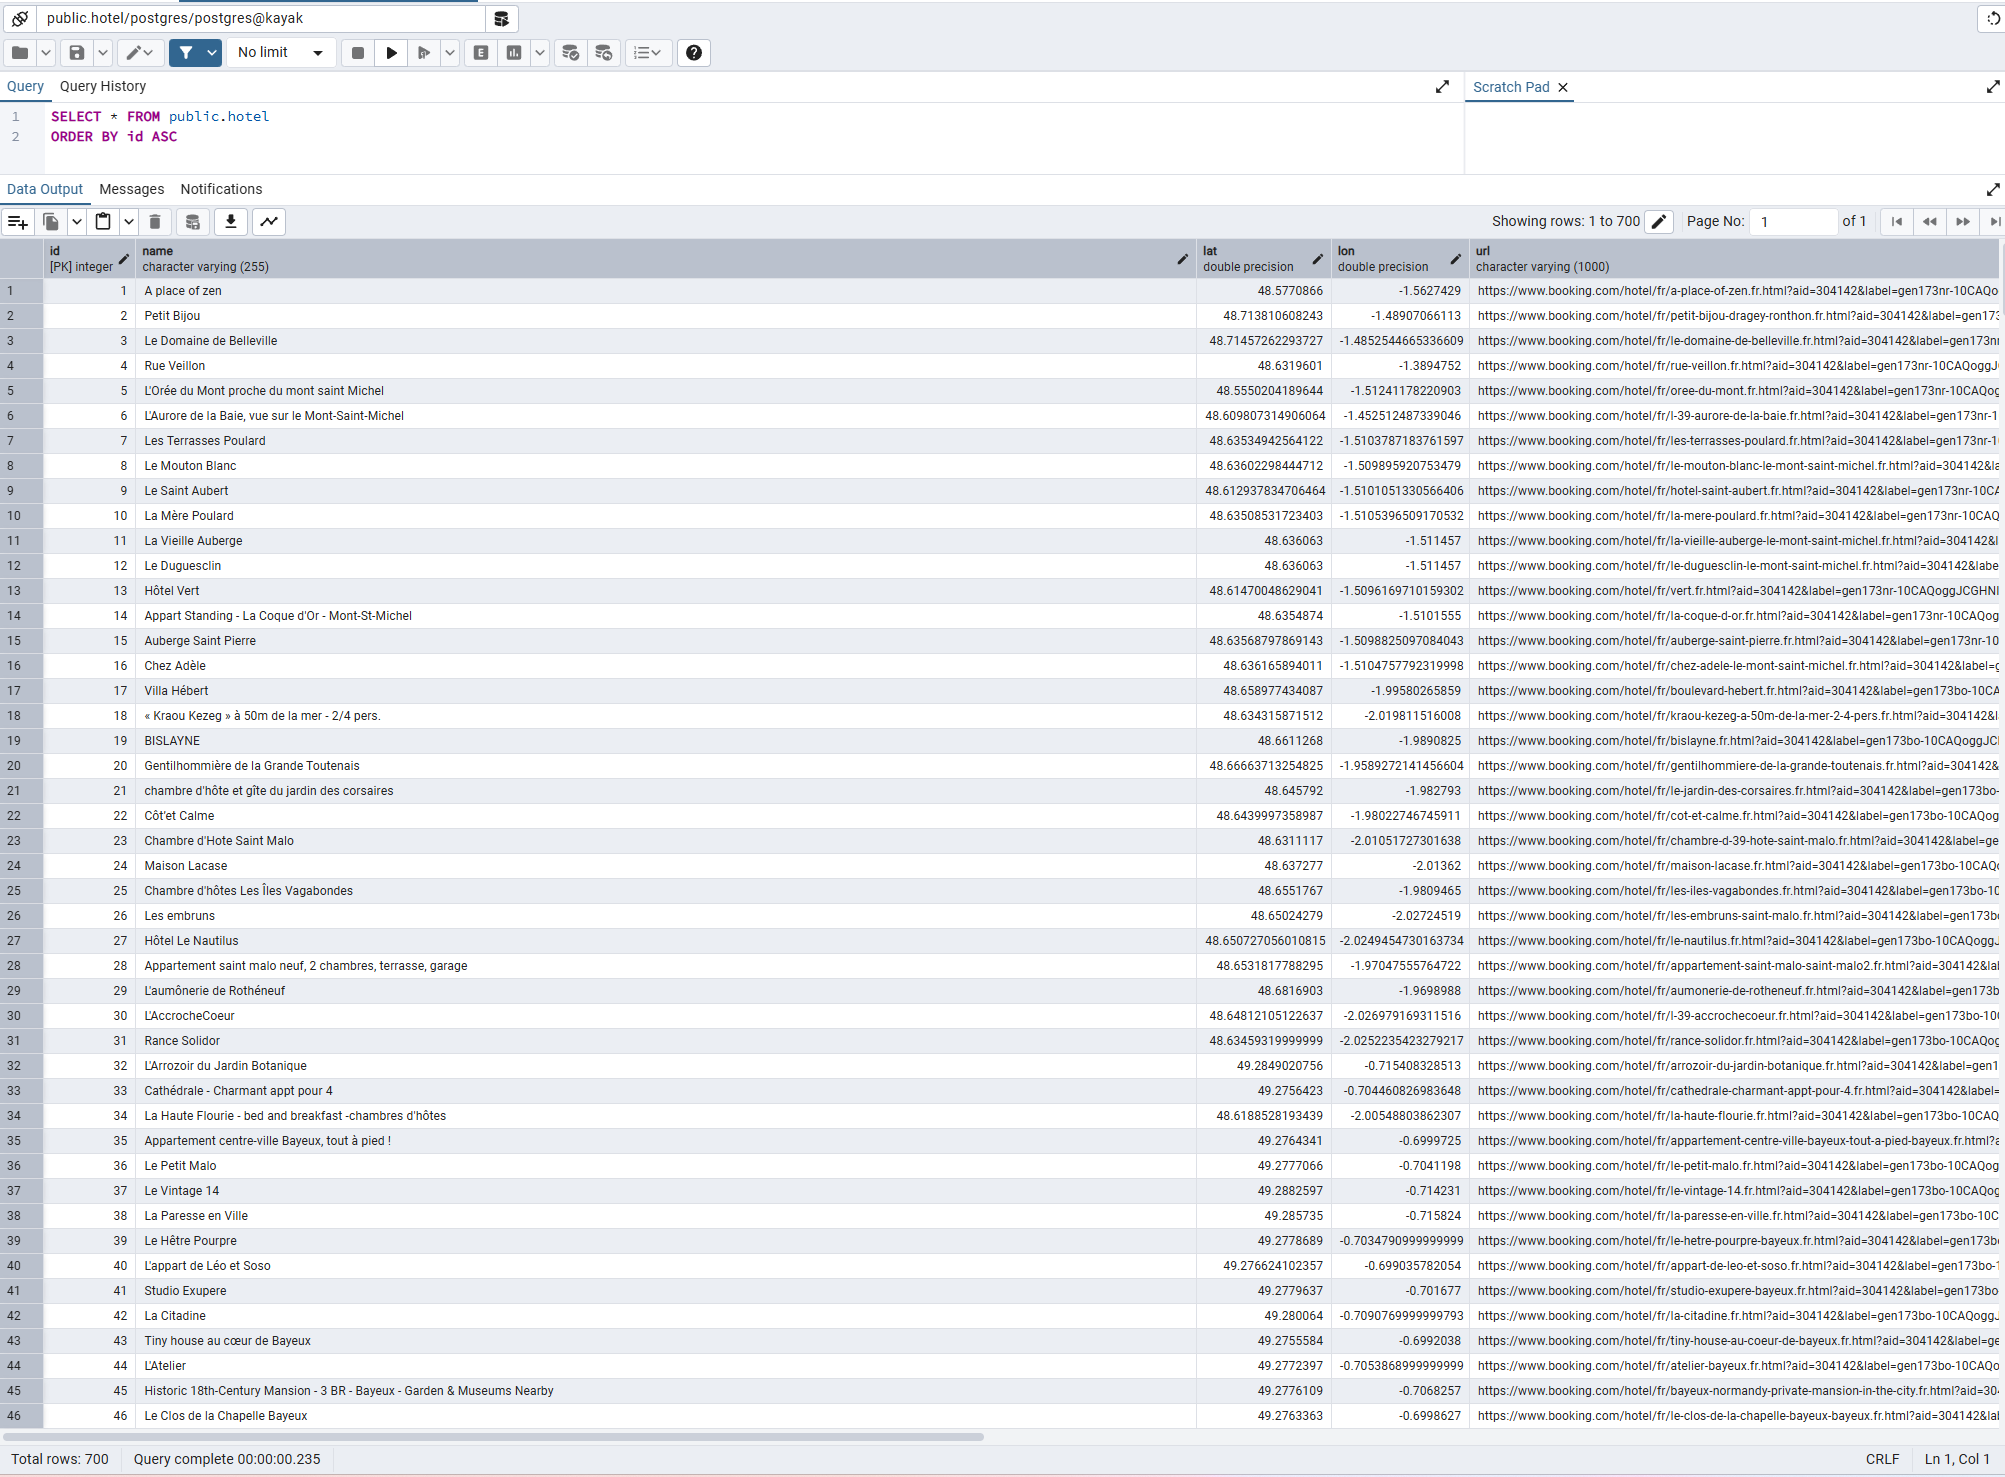

In [41]:
display(Image(filename="../images/hotel_table.png"))

### Execution d'une requête SQL

In [39]:
query = pd.read_sql("""
    SELECT c.city, h.name, h.review_score
    FROM city c INNER JOIN hotel h
    ON c.id = h.city_id
    ORDER BY c.city ASC, h.review_score DESC, h.name ASC
""", engine)
print(query)

2026-03-12 23:30:51,939 INFO sqlalchemy.engine.Engine BEGIN (implicit)
2026-03-12 23:30:51,940 INFO sqlalchemy.engine.Engine SELECT pg_catalog.pg_class.relname 
FROM pg_catalog.pg_class JOIN pg_catalog.pg_namespace ON pg_catalog.pg_namespace.oid = pg_catalog.pg_class.relnamespace 
WHERE pg_catalog.pg_class.relname = %(table_name)s AND pg_catalog.pg_class.relkind = ANY (ARRAY[%(param_1)s, %(param_2)s, %(param_3)s, %(param_4)s, %(param_5)s]) AND pg_catalog.pg_table_is_visible(pg_catalog.pg_class.oid) AND pg_catalog.pg_namespace.nspname != %(nspname_1)s
2026-03-12 23:30:51,941 INFO sqlalchemy.engine.Engine [cached since 29.62s ago] {'table_name': '\n    SELECT c.city, h.name, h.review_score\n    FROM city c INNER JOIN hotel h\n    ON c.id = h.city_id\n    ORDER BY c.city ASC, h.review_score DESC, h.name ASC\n', 'param_1': 'r', 'param_2': 'p', 'param_3': 'f', 'param_4': 'v', 'param_5': 'm', 'nspname_1': 'pg_catalog'}
2026-03-12 23:30:51,957 INFO sqlalchemy.engine.Engine 
    SELECT c.city,